In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("/content/Breaking Bad Dataset.csv" ,  encoding = "latin1")

In [26]:
df.head()

,Release date,Season,Episode,Title,Duration in minutes,U.S. viewers in millions,IMDB Rating,Director
0,20-Jan-08,1,1,Pilot,58,1.41,9.0,Vince Gilligan
1,27-Jan-08,1,2,Cat's in the Bag...,48,1.49,8.6,Adam Bernstein
2,10-Feb-08,1,3,...And the Bag's in the River,48,1.08,8.7,Adam Bernstein
3,17-Feb-08,1,4,Cancer Man,48,1.09,8.2,Jim McKay
4,24-Feb-08,1,5,Gray Matter,48,0.97,8.3,Tricia Brock


In [27]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [30]:
df.isnull().sum()

,0
Release date,0
Season,0
Episode,0
Title,0
Duration in minutes,0
U.S. viewers in millions,0
IMDB Rating,0
Director,0


In [29]:
df['U.S. viewers in millions'] = df['U.S. viewers in millions'].fillna(df['U.S. viewers in millions'].mean())

In [31]:
df.shape

(62, 8)

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.describe()

,Season,Episode,Duration in minutes,U.S. viewers in millions,IMDB Rating
count,62.000000,62.000000,62.000000,62.000000,62.000000
mean,3.290323,7.048387,47.919355,2.324386,8.956452
std,1.359690,4.074822,2.632074,1.647258,0.543703
min,1.000000,1.000000,43.000000,0.970000,7.800000
25%,2.000000,4.000000,47.000000,1.492500,8.525000
50%,3.000000,7.000000,47.000000,1.765000,8.850000
75%,4.750000,10.000000,48.000000,2.324386,9.375000
max,5.000000,16.000000,60.000000,10.280000,10.000000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Release date              62 non-null     object 
 1   Season                    62 non-null     int64  
 2   Episode                   62 non-null     int64  
 3   Title                     62 non-null     object 
 4   Duration in minutes       62 non-null     int64  
 5   U.S. viewers in millions  62 non-null     float64
 6   IMDB Rating               62 non-null     float64
 7   Director                  62 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 4.0+ KB


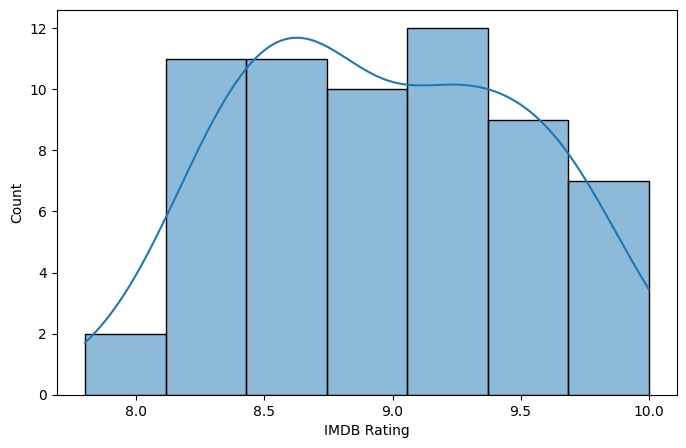

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(data = df, x = "IMDB Rating", kde = True)
plt.show()


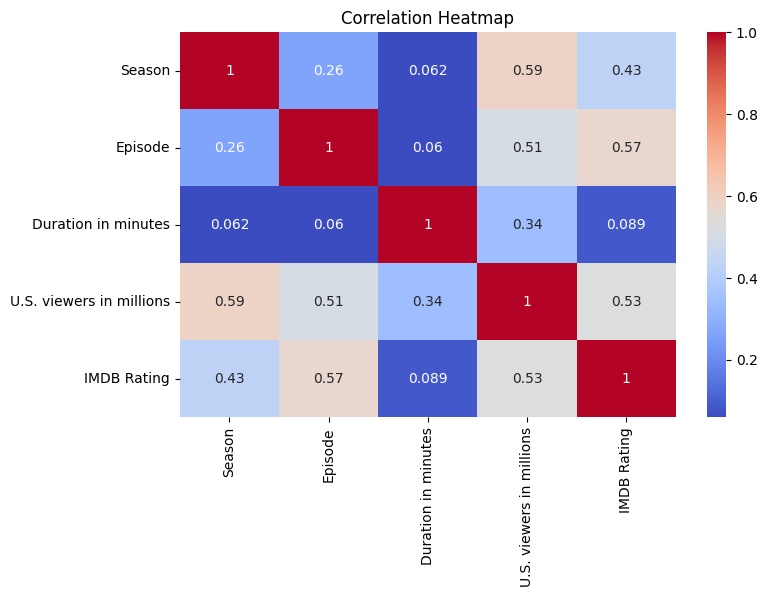

In [38]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

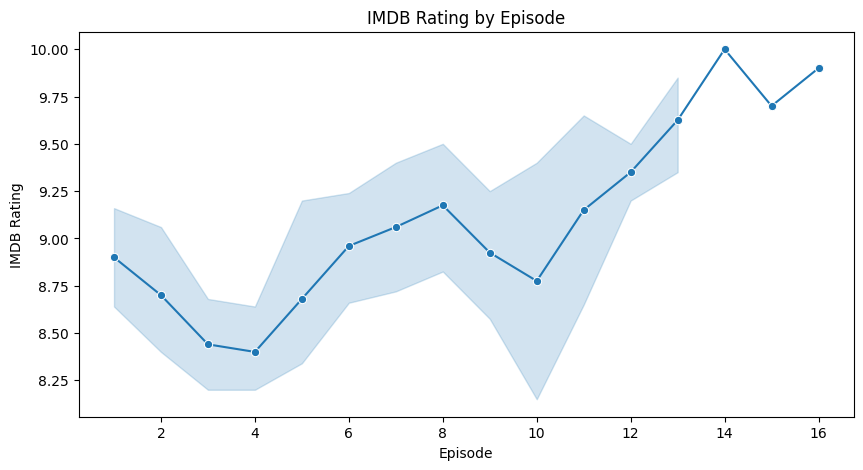

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.lineplot(
    x='Episode',
    y='IMDB Rating',
    data=df,
    marker='o'
)

plt.title('IMDB Rating by Episode')
plt.xlabel('Episode')
plt.ylabel('IMDB Rating')

plt.show()

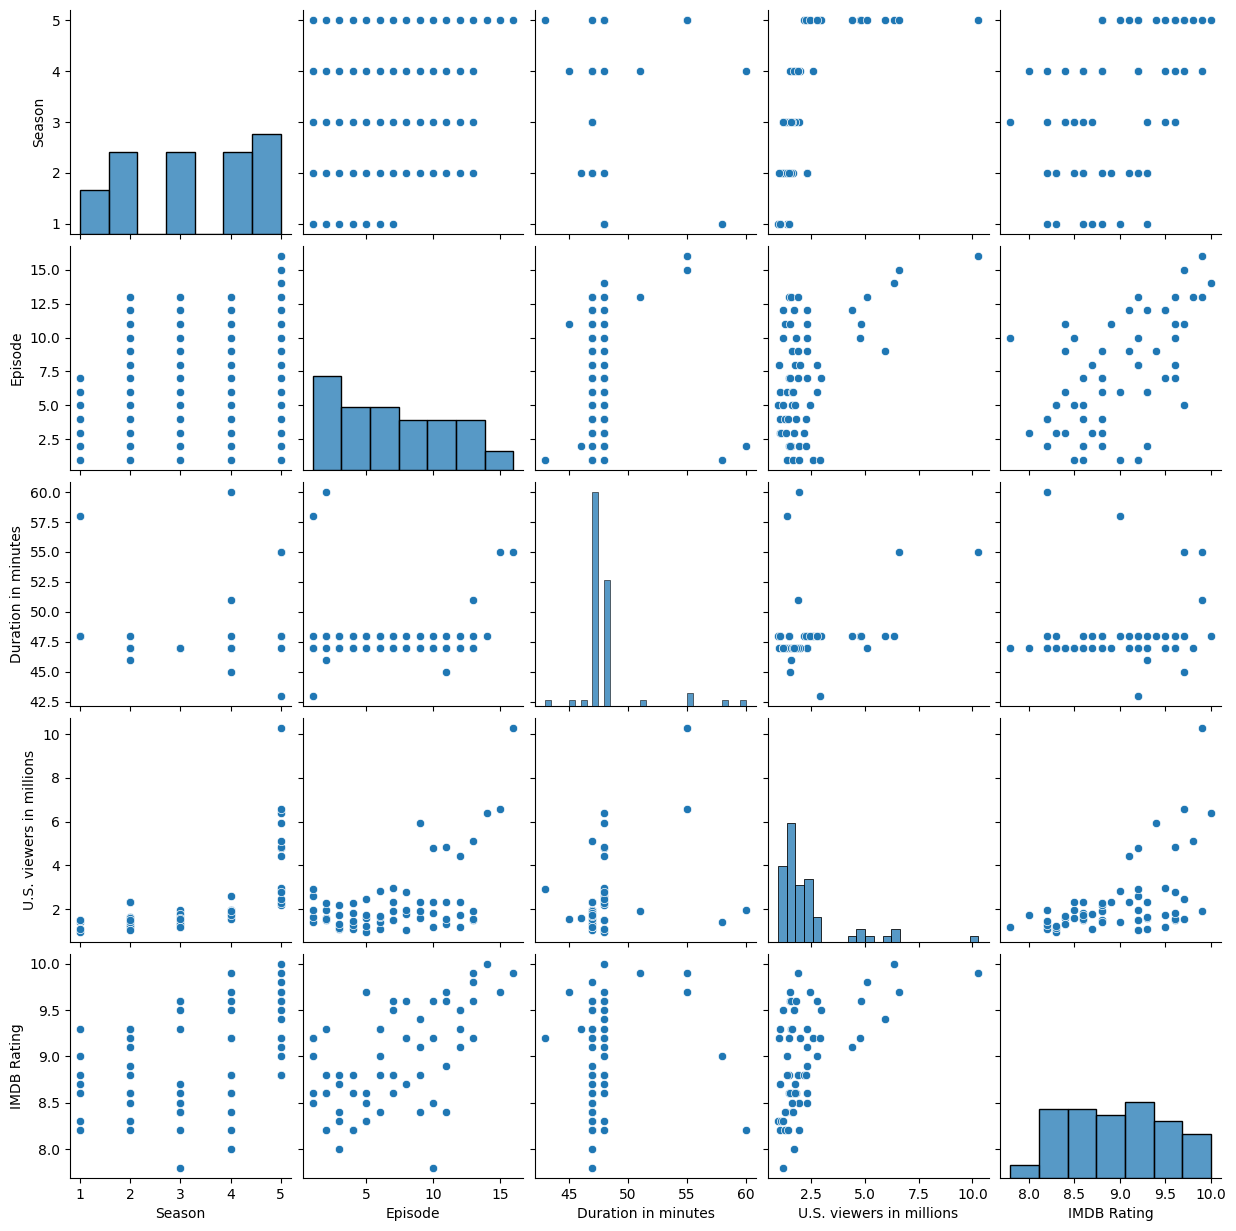

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sirf numeric columns
numeric_df = df.select_dtypes(include='number')

sns.pairplot(numeric_df)

plt.show()

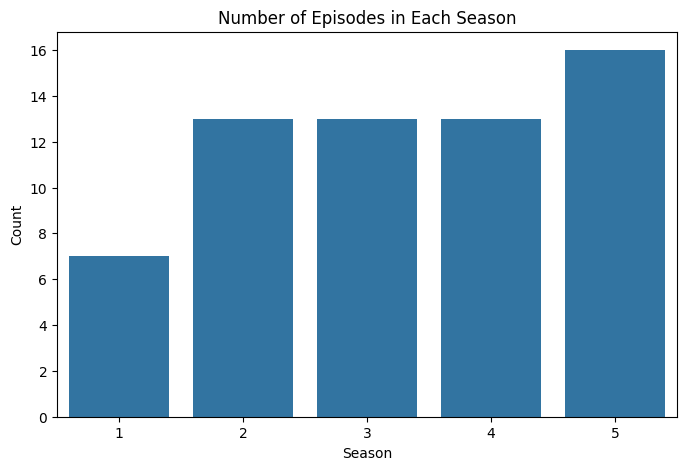

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='Season',
    data=df
)

plt.title('Number of Episodes in Each Season')
plt.xlabel('Season')
plt.ylabel('Count')

plt.show()

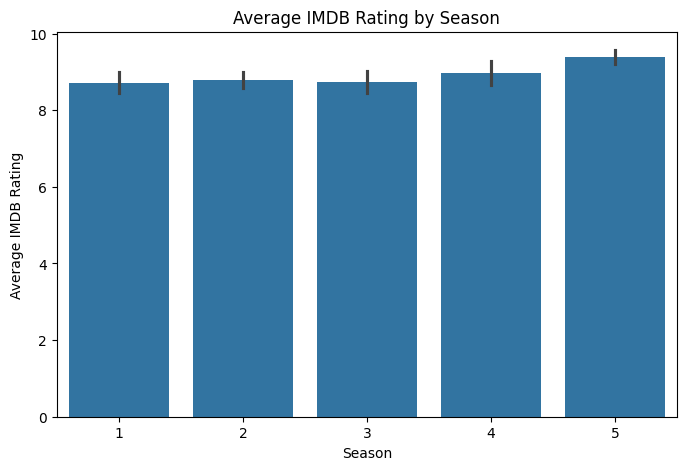

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x='Season',
    y='IMDB Rating',
    data=df
)

plt.title('Average IMDB Rating by Season')
plt.xlabel('Season')
plt.ylabel('Average IMDB Rating')

plt.show()

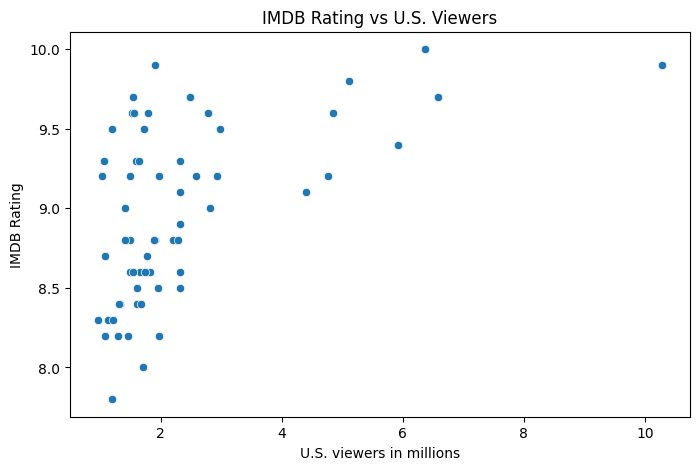

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='U.S. viewers in millions',
    y='IMDB Rating',
    data=df
)

plt.title('IMDB Rating vs U.S. Viewers')
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [41]:
X = df[['Season', 'Episode', 'Duration in minutes', 'U.S. viewers in millions']]
y = df['IMDB Rating']


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [43]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
predictions = model.predict(X_test)
print(predictions)

[8.95509922 9.54126322 7.88538162 9.57839926 8.55736241 8.79669871
 9.05079494 8.70829226 8.81610392 9.85864092 9.1381302  8.48084492
 8.73417909]


In [47]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: -0.15362944240831689


In [48]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 0.5355719674953578
